In [1]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.models.data_selector import Data_selector
from src.models.filter_data.feature_adder import Feature_adder
from src.models.feature_selector import Feature_selector
from logs.logger import CustomLogger
from src.models.models import Random_Forest, Linear, Polynomial, XGBoost, LinearL1
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

logger = CustomLogger(name="model_main").get_logger()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [5]:
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
mask = df["is_good_peak"] == 3
df = df[mask]

df['date'] = pd.to_datetime(df['date'])
df['datetime'] = df['date'] + pd.to_timedelta(df['hour'], unit='h')

code = "G11"
name = "پرند"
mask = (df["name"] == name) & (df['code'] == code)

df = df[mask]

In [6]:
dff = pd.DataFrame(df["generation"], index=df["datetime"])

In [4]:
# تولید داده نمونه (می‌توانید با داده‌های واقعی جایگزین کنید)
np.random.seed(42)
n = 200
time = np.arange(n)
trend = 0.1 * time
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 1, n)*0
data = trend + seasonality + noise + 50

# ایجاد DataFrame
dates = pd.date_range(start='2010-01-01', periods=n, freq='M')
df = pd.DataFrame({'value': data}, index=dates)

print("نمونه داده‌ها:")
print(df.head())

نمونه داده‌ها:
                value
2010-01-31  50.000000
2010-02-28  55.100000
2010-03-31  58.860254
2010-04-30  60.300000
2010-05-31  59.060254


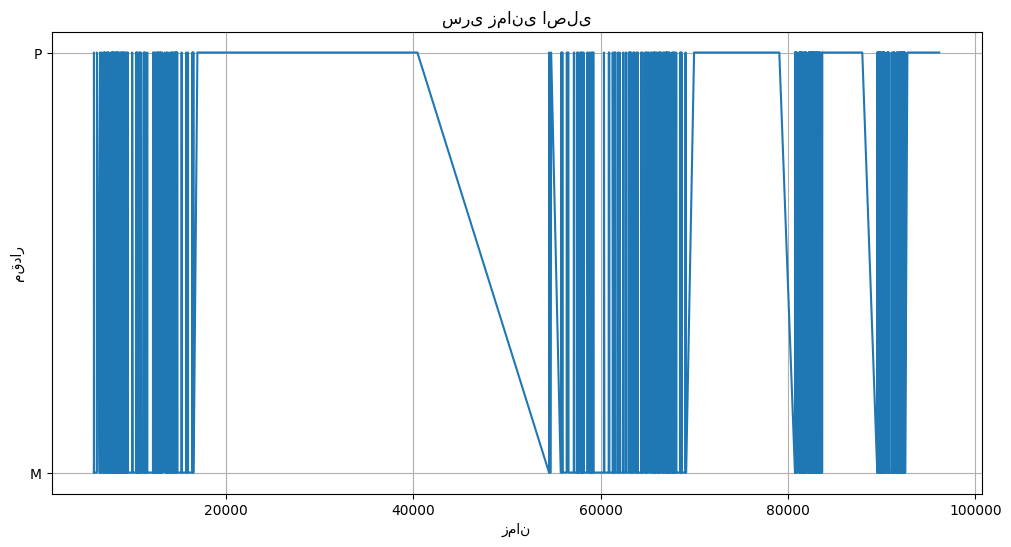

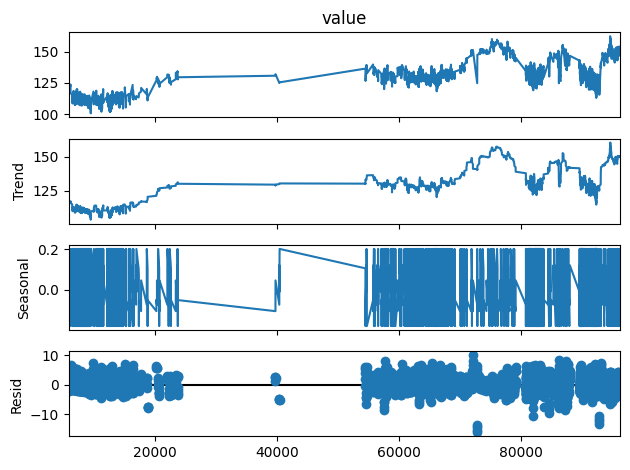

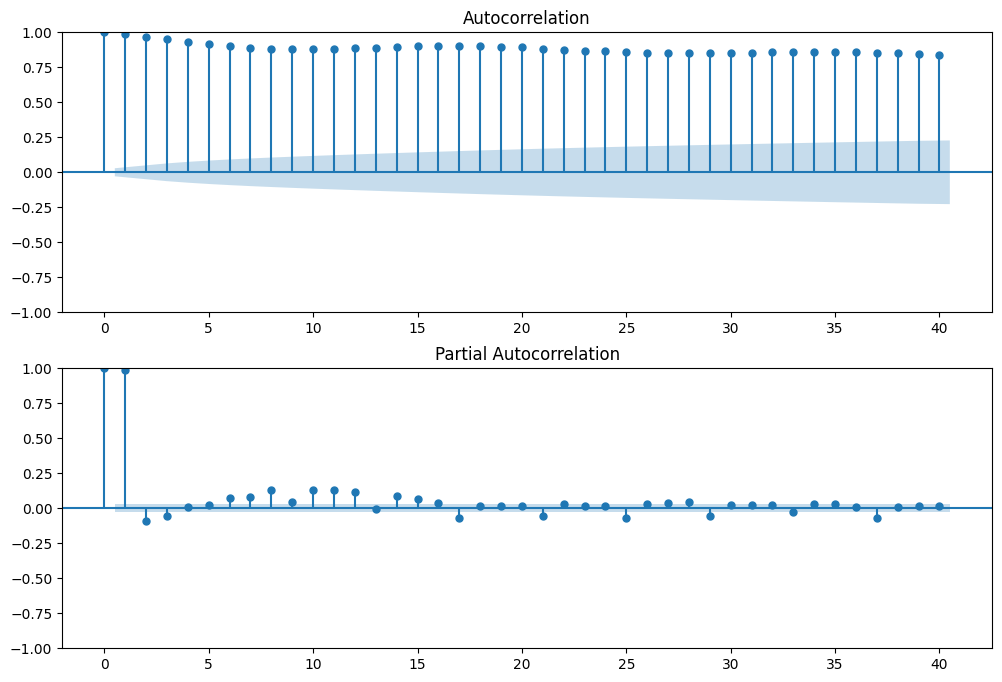

In [8]:
# نمایش داده‌ها
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['value'])
plt.title('سری زمانی اصلی')
plt.xlabel('زمان')
plt.ylabel('مقدار')
plt.grid(True)
plt.show()
df['value'] = df["generation"]
# تجزیه سری زمانی
decomposition = seasonal_decompose(df['value'], model='additive', period=12)
decomposition.plot()
plt.show()

# ACF و PACF برای تشخیص پارامترها
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['value'], ax=ax1, lags=40)
plot_pacf(df['value'], ax=ax2, lags=40)
plt.show()

In [9]:
# تقسیم داده
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"تعداد داده‌های آموزش: {len(train)}")
print(f"تعداد داده‌های تست: {len(test)}")

تعداد داده‌های آموزش: 3677
تعداد داده‌های تست: 920


In [10]:
# تعریف پارامترهای SARIMA
# SARIMA(p, d, q)(P, D, Q, s)
p, d, q = 1, 1, 1          # پارامترهای غیر فصلی
P, D, Q, s = 1, 1, 1, 12   # پارامترهای فصلی (s=12 برای داده ماهانه)

# آموزش مدل
model = SARIMAX(train['value'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                 3677
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -7638.385
Date:                            Sun, 28 Sep 2025   AIC                          15286.771
Time:                                    16:26:37   BIC                          15317.783
Sample:                                         0   HQIC                         15297.815
                                           - 3677                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3600      0.163      2.211      0.027       0.041       0.679
ma.L1         -0.2627      0.165   

MAE: 9.87
MSE: 225.76
RMSE: 15.03


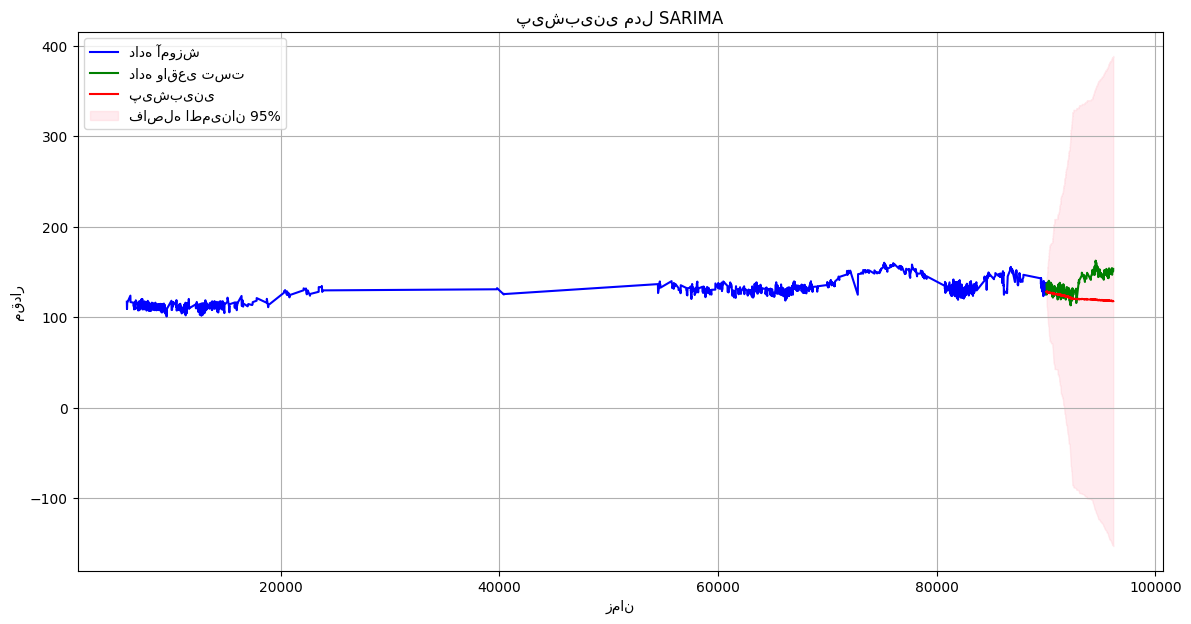

In [11]:
# پیش‌بینی
forecast_steps = len(test)
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# محاسبه معیارهای ارزیابی
mae = mean_absolute_error(test['value'], forecast_mean)
mse = mean_squared_error(test['value'], forecast_mean)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# نمایش نتایج
plt.figure(figsize=(14, 7))
plt.plot(train.index, train['value'], label='داده آموزش', color='blue')
plt.plot(test.index, test['value'], label='داده واقعی تست', color='green')
plt.plot(test.index, forecast_mean, label='پیش‌بینی', color='red')
plt.fill_between(test.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='فاصله اطمینان 95%')
plt.title('پیش‌بینی مدل SARIMA')
plt.xlabel('زمان')
plt.ylabel('مقدار')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from pmdarima import auto_arima

# استفاده از auto_arima برای تشخیص خودکار پارامترها
auto_model = auto_arima(df['value'],
                        seasonal=True,
                        m=12,  # دوره فصلی
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print(auto_model.summary())

# پیش‌بینی با مدل بهینه
auto_forecast = auto_model.predict(n_periods=len(test))

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=18860.505, Time=11.64 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=19372.720, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=19333.468, Time=0.74 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=19338.071, Time=0.85 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=19370.792, Time=0.04 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=18911.811, Time=7.63 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=18908.286, Time=9.46 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=18821.198, Time=29.94 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=18886.884, Time=23.97 sec


KeyboardInterrupt: 

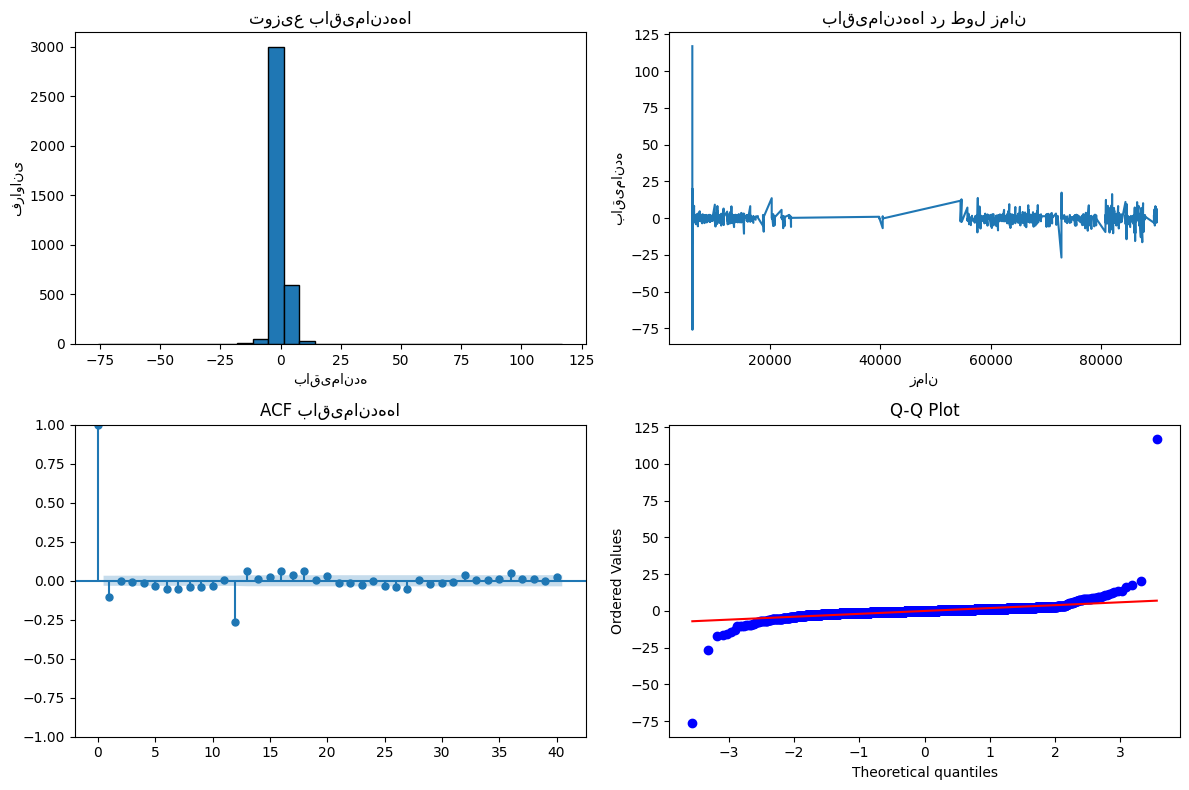

In [13]:
# تحلیل باقیمانده‌ها
residuals = results.resid

plt.figure(figsize=(12, 8))

# توزیع باقیمانده‌ها
plt.subplot(2, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('توزیع باقیمانده‌ها')
plt.xlabel('باقیمانده')
plt.ylabel('فراوانی')

# باقیمانده‌ها در زمان
plt.subplot(2, 2, 2)
plt.plot(residuals)
plt.title('باقیمانده‌ها در طول زمان')
plt.xlabel('زمان')
plt.ylabel('باقیمانده')

# ACF باقیمانده‌ها
plt.subplot(2, 2, 3)
plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('ACF باقیمانده‌ها')

# Q-Q Plot
plt.subplot(2, 2, 4)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

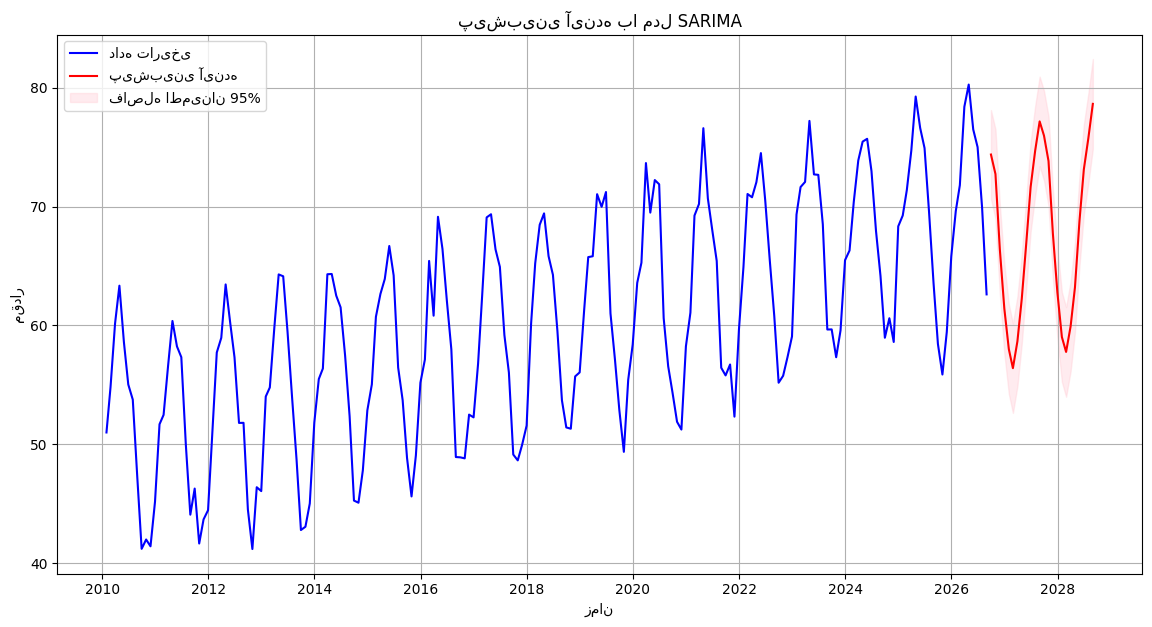

In [ ]:
# پیش‌بینی برای آینده
future_steps = 24
future_forecast = results.get_forecast(steps=future_steps)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

# ایجاد ایندکس برای آینده
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1),
                            periods=future_steps,
                            freq='M')

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['value'], label='داده تاریخی', color='blue')
plt.plot(future_dates, future_mean, label='پیش‌بینی آینده', color='red')
plt.fill_between(future_dates,
                 future_ci.iloc[:, 0],
                 future_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='فاصله اطمینان 95%')
plt.title('پیش‌بینی آینده با مدل SARIMA')
plt.xlabel('زمان')
plt.ylabel('مقدار')
plt.legend()
plt.grid(True)
plt.show()